# Native vertical velocity within fitted eddy cores

Explore selected eddy-days before choosing one vertical-velocity metric for a population analysis. The NetCDF `w` is upward velocity (m/s); the fitted profile column `w` is relative vorticity (s⁻¹). Per-depth fitted centres and ellipses define the sampling region. The model snapshot is converted to `(x, y, z)` as in the modular dataset pipeline; the extra surface `s_w` level is dropped from model `w` so the remaining 30 levels align directly with the 30 levels of `z_r`.


In [1]:
from pathlib import Path
import sys
import netCDF4 as nc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

HERE = Path.cwd()
if HERE.name != 'vertical_velocity':
    raise RuntimeError('Launch this notebook from the vertical_velocity folder')
sys.path.insert(0, str(HERE.parent))
sys.path.insert(0, str(HERE.parent / 'case_studies' / 'eddy_cross_sections_3d'))
import seacofs_tilt_tools as tilt
from case_section_tools import resolve_model_file
from vertical_velocity_tools import sample_snapshot, column_extrema


In [2]:
# Edit these controls after looking at the available IDs and days below.
CASES = [(184,2119), (1528,6189), (1526,6189), (2540,9228)]  # e.g. [(123, 4567), (321, 4568)]
FRACTIONS = (0.5, 1.0, 1.5)
MAX_DEPTH_M = 1000
MAX_MISMATCH_M = 75
MAP_DEPTHS_M = (50, 200, 500)
MODEL_ROOT = Path('/srv/scratch/z3533156/26year_BRAN2020')


In [3]:
surface, _ = tilt.load_tilt_tables()
vertical = tilt.load_vert()
grid = tilt.load_grid()
print(f'{len(surface):,} surface eddy-days; {len(vertical):,} fitted depth rows')
display(surface[['Eddy','Day','Cyc','TiltDis','fname']].head(15))
print('Example well-resolved eddy-days:')
counts = vertical.loc[vertical.Depth.le(MAX_DEPTH_M)].groupby(['Eddy','Day']).Depth.nunique().sort_values(ascending=False)
display(counts.head(20).rename('n_fitted_depths').reset_index().merge(surface[['Eddy','Day','Cyc','TiltDis']],on=['Eddy','Day'],how='left'))


127,426 surface eddy-days; 2,824,609 fitted depth rows


,Eddy,Day,Cyc,TiltDis,fname
0,1,1462,CE,NaN,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
1,1,1463,CE,NaN,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
2,1,1464,CE,NaN,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
3,1,1465,CE,19.823350,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
4,1,1466,CE,15.055658,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
5,1,1467,CE,8.821740,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
6,1,1468,CE,5.770986,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
7,1,1469,CE,4.014082,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
8,1,1470,CE,2.294209,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
9,1,1471,CE,1.540758,/srv/scratch/z3533156/26year_BRAN2020/outer_av...


Example well-resolved eddy-days:


,Eddy,Day,n_fitted_depths,Cyc,TiltDis
0,2982,10650,22,CE,NaN
1,1,1462,22,CE,NaN
2,1,1463,22,CE,NaN
3,1,1464,22,CE,NaN
4,1,1465,22,CE,19.823350
5,1,1466,22,CE,15.055658
6,1,1467,22,CE,8.821740
7,1,1468,22,CE,5.770986
8,1,1470,22,CE,2.294209
9,1,1471,22,CE,1.540758


Set `CASES` above, then run the remaining cells. Each `(Eddy, Day)` must have a surface row and a fitted vertical profile. Source files are read one snapshot at a time.


In [4]:
if not CASES:
    raise ValueError('Set CASES in the controls cell first')
all_depth, all_column, all_maps = [], [], {}
for eddy, day in CASES:
    s = surface.loc[surface.Eddy.eq(eddy) & surface.Day.eq(day)]
    profile = vertical.loc[vertical.Eddy.eq(eddy) & vertical.Day.eq(day)].sort_values('Depth')
    if len(s) != 1 or profile.empty:
        raise ValueError(f'Expected one surface row and a profile for {(eddy,day)}')
    path = resolve_model_file(s.iloc[0], MODEL_ROOT)
    print(f'{(eddy,day)}: {path.name}, {len(profile)} fitted levels')
    with nc.Dataset(path) as ds:
        depth, maps = sample_snapshot(ds, profile.iloc[0], profile.Depth.unique(), grid,
            fractions=FRACTIONS, max_depth_m=MAX_DEPTH_M, max_mismatch_m=MAX_MISMATCH_M)
    depth['TiltDis_km'] = s.iloc[0].TiltDis
    all_depth.append(depth)
    all_column.append(column_extrema(depth))
    all_maps[(eddy,day)] = maps
per_depth = pd.concat(all_depth, ignore_index=True)
per_column = pd.concat(all_column, ignore_index=True)
display(per_column)
display(per_depth[['Eddy','Day','fraction','Depth','n_core','n_valid','coverage','w_min','w_max','w_mean','z_min_m','z_max_m']])


(184, 2119): outer_avg_02091.nc, 29 fitted levels
(1528, 6189): outer_avg_06171.nc, 25 fitted levels
(1526, 6189): outer_avg_06171.nc, 30 fitted levels
(2540, 9228): outer_avg_09201.nc, 24 fitted levels


,Eddy,Day,fraction,w_max,max_depth_m,w_min,min_depth_m,w_abs_max,n_depths,min_coverage
0,184,2119,0.5,0.000485,180.931540,-0.000558,218.647311,-0.000558,22,1.000000
1,184,2119,1.0,0.000485,180.931540,-0.000558,218.647311,-0.000558,22,1.000000
2,184,2119,1.5,0.000485,180.931540,-0.000558,218.647311,-0.000558,22,0.953890
3,1528,6189,0.5,0.000082,405.778534,-0.000097,647.640859,-0.000097,22,1.000000
4,1528,6189,1.0,0.000153,181.476820,-0.000192,267.168763,-0.000192,22,1.000000
5,1528,6189,1.5,0.000243,217.964967,-0.000236,515.460129,0.000243,22,0.978387
6,1526,6189,0.5,0.000072,828.508438,-0.000100,826.249553,-0.000100,22,1.000000
7,1526,6189,1.0,0.000142,320.183092,-0.000145,822.644332,-0.000145,22,0.994688
8,1526,6189,1.5,0.000210,220.035823,-0.000243,266.926197,-0.000243,22,0.997647
9,2540,9228,0.5,0.000052,471.850117,-0.000082,895.038189,-0.000082,22,0.541899


,Eddy,Day,fraction,Depth,n_core,n_valid,coverage,w_min,w_max,w_mean,z_min_m,z_max_m
0,184,2119,0.5,0.000000,243,243,1.000000,-0.000013,0.000010,1.789291e-06,1.783178,1.782728
1,184,2119,0.5,5.879627,243,243,1.000000,-0.000030,0.000021,1.687914e-06,5.879079,5.877352
2,184,2119,0.5,10.725783,243,243,1.000000,-0.000050,0.000035,1.491778e-06,10.724624,10.720975
3,184,2119,0.5,16.383097,243,243,1.000000,-0.000073,0.000050,1.141112e-06,16.381057,16.374639
4,184,2119,0.5,22.925581,243,243,1.000000,-0.000098,0.000069,5.354175e-07,22.922314,22.912042
...,...,...,...,...,...,...,...,...,...,...,...,...
259,2540,9228,1.5,327.440851,1625,1625,1.000000,-0.000107,0.000137,1.893497e-05,319.769065,311.497577
260,2540,9228,1.5,407.922192,1625,1625,1.000000,-0.000086,0.000123,1.996546e-05,393.836657,388.946602
261,2540,9228,1.5,515.416489,1625,1625,1.000000,-0.000128,0.000124,1.970087e-05,497.549584,485.826874
262,2540,9228,1.5,660.806374,1625,1505,0.926154,-0.000177,0.000134,1.987594e-05,636.231211,637.771437


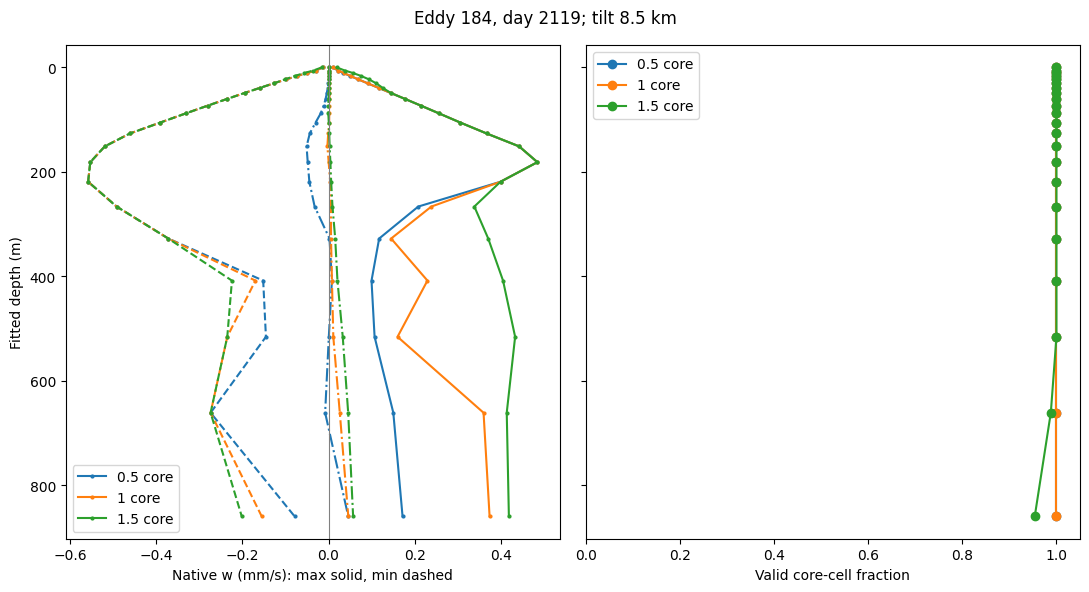

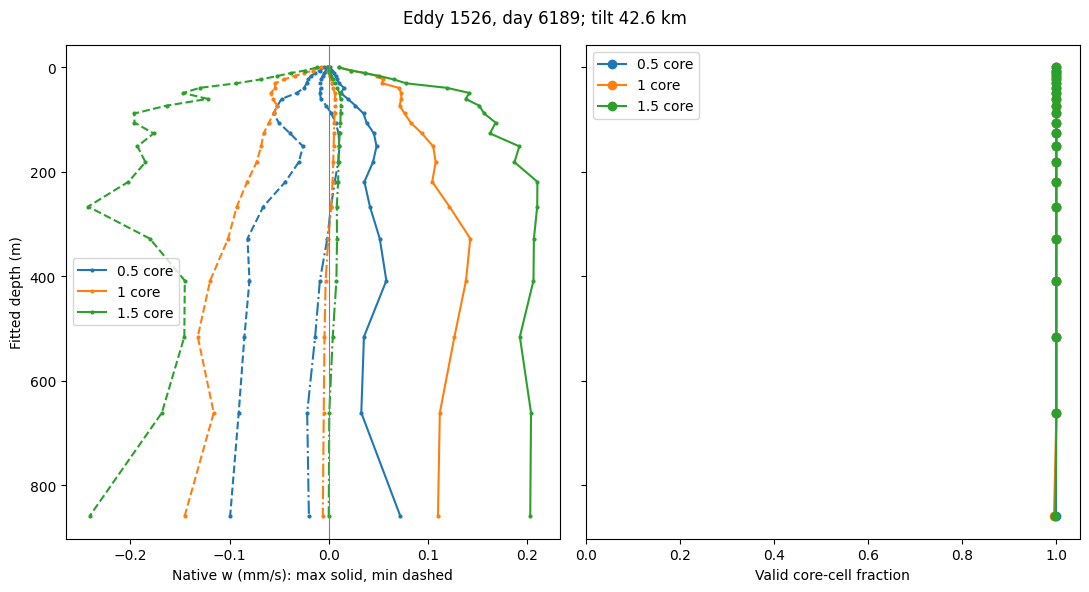

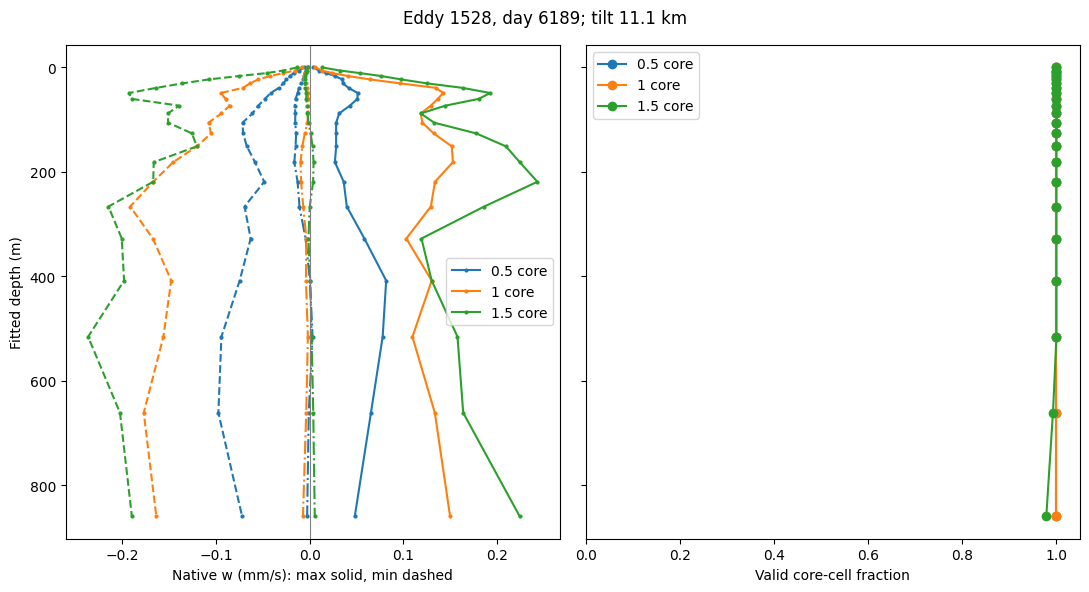

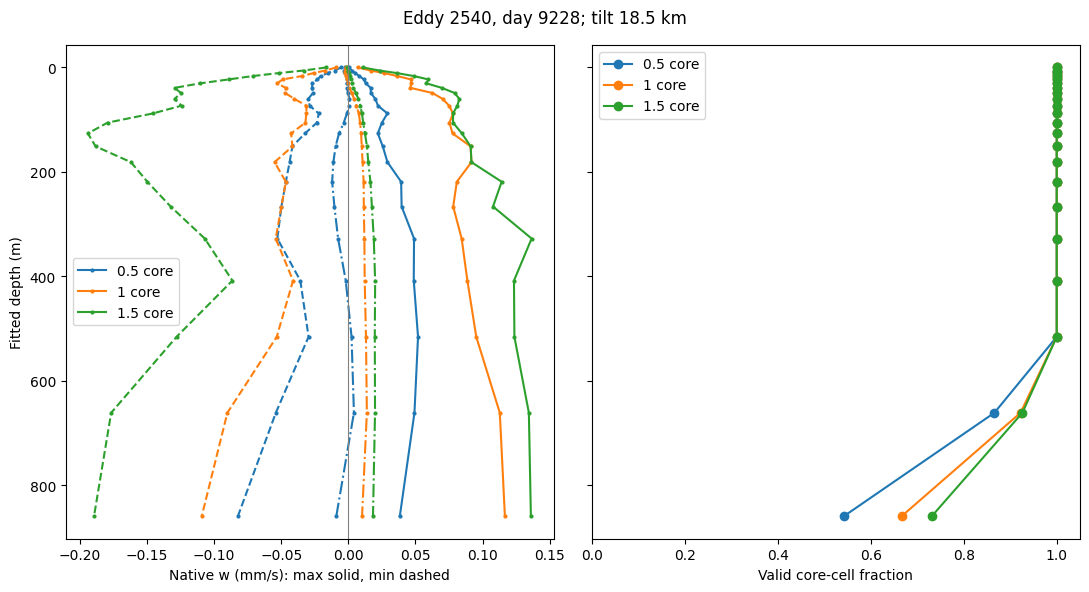

In [5]:
# Positive is upward. Compare extrema and mean as functions of fitted depth.
mkr_s = 2
for (eddy, day), group in per_depth.groupby(['Eddy','Day']):
    fig, axes = plt.subplots(1, 2, figsize=(11,6), sharey=True)
    for fraction, g in group.groupby('fraction'):
        g = g.sort_values('Depth')
        axes[0].plot(1e3*g.w_max, g.Depth, 'o-', label=f'{fraction:g} core', markersize=mkr_s)
        axes[0].plot(1e3*g.w_mean, g.Depth, 'o-.', color=axes[0].lines[-1].get_color(), markersize=mkr_s)
        axes[0].plot(1e3*g.w_min, g.Depth, 'o--', color=axes[0].lines[-1].get_color(), markersize=mkr_s)
        axes[1].plot(g.coverage, g.Depth, 'o-', label=f'{fraction:g} core')
    axes[0].axvline(0,color='0.5',lw=0.8)
    axes[0].set(xlabel='Native w (mm/s): max solid, min dashed', ylabel='Fitted depth (m)')
    axes[1].set(xlabel='Valid core-cell fraction', xlim=(0,1.05))
    axes[0].invert_yaxis()
    axes[0].legend()
    axes[1].legend()
    fig.suptitle(f'Eddy {eddy}, day {day}; tilt {group.TiltDis_km.iloc[0]:.1f} km')
    fig.tight_layout()
    plt.show()


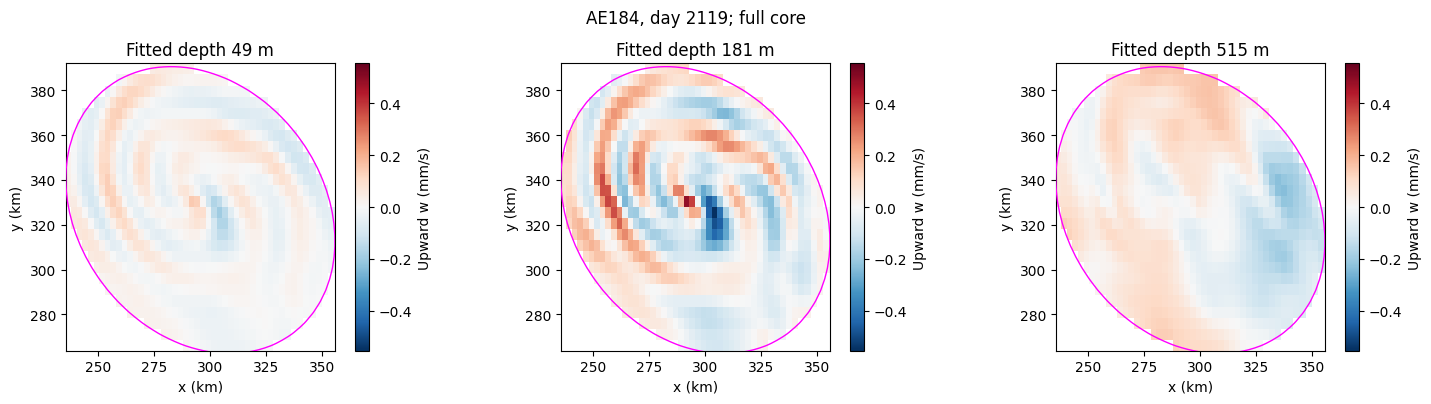

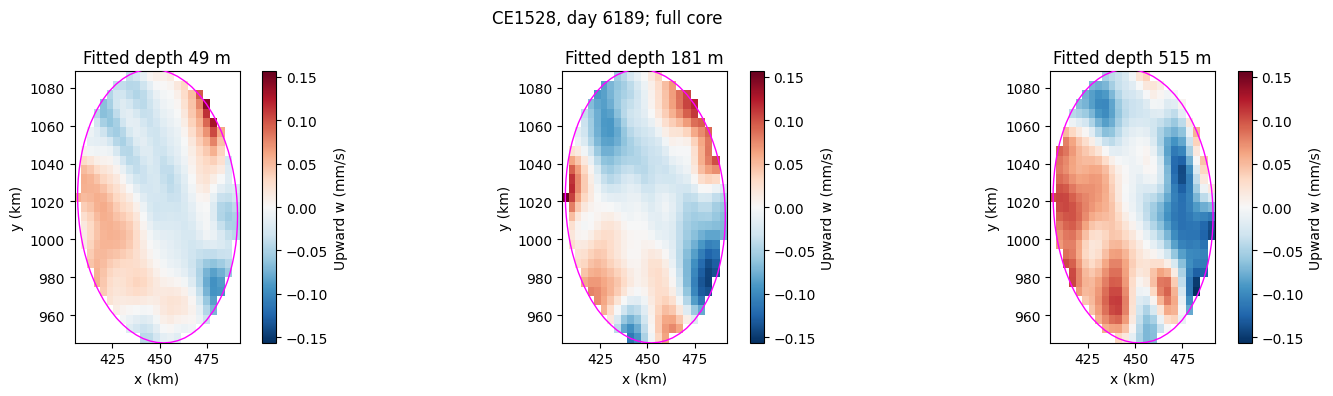

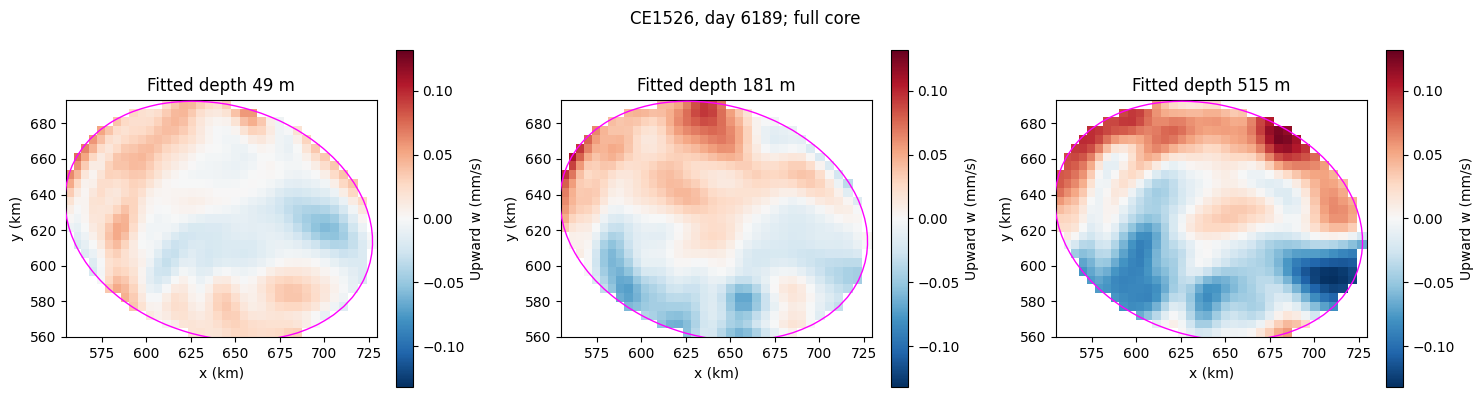

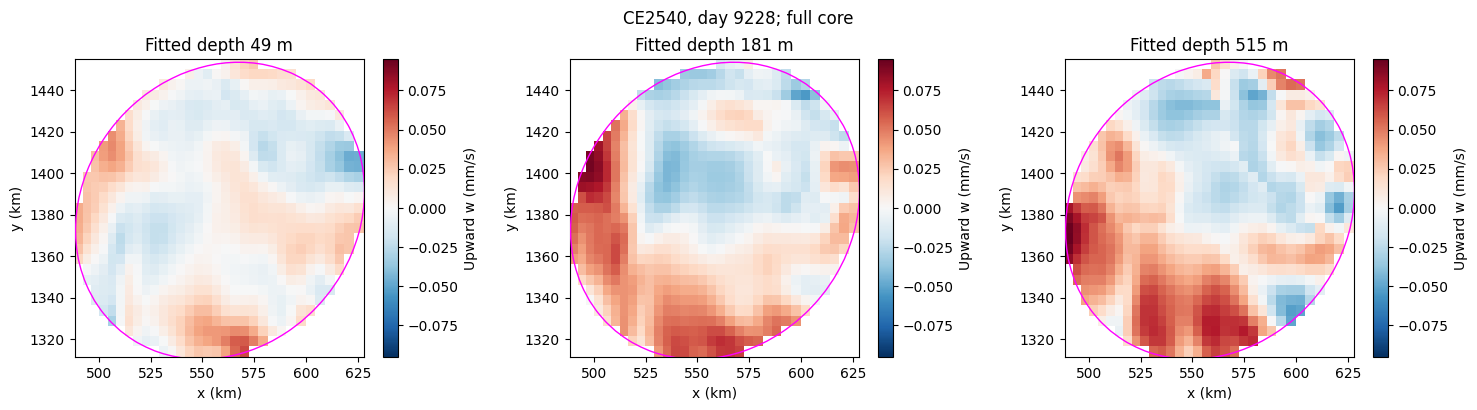

In [6]:
# Local maps: show the full-core footprint at a few available fitted depths.
for (eddy, day), maps in all_maps.items():
    levels = sorted({d for f,d in maps if f == 1.0})
    chosen = [min(levels, key=lambda d:abs(d-target)) for target in MAP_DEPTHS_M] if levels else []
    chosen = list(dict.fromkeys(chosen))
    if not chosen: continue
    vmax = max(np.nanmax(np.abs(maps[(1.0,d)][0])) for d in chosen)
    fig, axes = plt.subplots(1,len(chosen),figsize=(5*len(chosen),4),squeeze=False)
    for ax,d in zip(axes[0],chosen):
        field,(i0,i1,j0,j1) = maps[(1.0,d)]
        img=ax.pcolormesh(grid.x_grid[i0:i1],grid.y_grid[j0:j1],(1e3*field).T,
                          cmap='RdBu_r',vmin=-1e3*vmax,vmax=1e3*vmax,shading='auto')
        row = surface[(surface.Eddy==eddy)&(surface.Day==day)].iloc[0].copy()
        xlim, ylim = ax.get_xlim(), ax.get_ylim()
        tilt.plot_ellipse(ax, row, grid=grid, zorder=10, color='magenta')
        ax.set(title=f'Fitted depth {d:.0f} m',xlabel='x (km)',ylabel='y (km)',aspect='equal', xlim=xlim, ylim=ylim)
        fig.colorbar(img,ax=ax,label='Upward w (mm/s)')
    cyc = surface[surface.Eddy==eddy].iloc[0].Cyc
    fig.suptitle(f'{cyc}{eddy}, day {day}; full core')
    fig.tight_layout()
    plt.show()


## Choosing a metric

Inspect whether extrema recur at similar depths and locations, whether they remain stable as the core fraction changes, and whether coverage is adequate. A minimum and maximum should be retained separately: averaging signed extrema can conceal a strong upwelling/downwelling dipole. For a later tilt correlation, compare these extrema with robust alternatives such as upper/lower core percentiles or area means, then bootstrap whole eddy tracks.
